# Aqueous Solubility Prediction (ESOL Dataset)

## Introduction
The objective of this notebook is to predict aqueous solubility (logS, mol/L) from molecular structure using RDKit and Morgan fingerprints on the ESOL benchmark dataset [1]. Three types of model were used: linear regression, random forest and gradient boosting.

## 1. Imports and Dependencies
Loading required libraries:
- **RDKit**: molecular manipulation from SMILES representations
- **scikit-learn**: ML models and evaluation metrics
- **pandas/numpy**: data manipulation and numerical computation
- **matplotlib/seaborn**: visualization

In [38]:
# Librairies de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# RDKit - manipulation de molécules
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score


## 2. Data Loading
ESOL dataset (Delaney, 2004) — 1128 molecules with experimentally measured
aqueous solubility (logS in mol/L). Loaded directly from the DeepChem repository.

In [39]:
# Dataset ESOL loading (Delaney 2004)
url = "https://raw.githubusercontent.com/deepchem/deepchem/master/datasets/delaney-processed.csv"
df = pd.read_csv(url)

print(f"Dataset dimensions : {df.shape}")
print(f"\nColumns : {df.columns.tolist()}")
print(f"\nFirst lines :")
df.head()

Dataset dimensions : (1128, 10)

Columns : ['Compound ID', 'ESOL predicted log solubility in mols per litre', 'Minimum Degree', 'Molecular Weight', 'Number of H-Bond Donors', 'Number of Rings', 'Number of Rotatable Bonds', 'Polar Surface Area', 'measured log solubility in mols per litre', 'smiles']

First lines :


,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.33,c1ccsc1


## 3. Data Exploration
Checking the distribution of logS values.
Note: the dataset is imbalanced — very few highly soluble molecules (logS > 0),
which explains the poorer model performance in that region.

Descriptive statistics :
count    1128.000000
mean       -3.050102
std         2.096441
min       -11.600000
25%        -4.317500
50%        -2.860000
75%        -1.600000
max         1.580000
Name: measured log solubility in mols per litre, dtype: float64


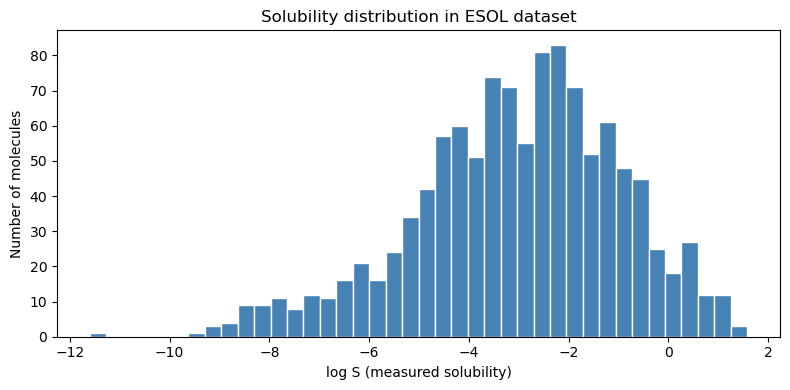

In [40]:
# Basic statistics
print("Descriptive statistics :")
print(df['measured log solubility in mols per litre'].describe())

# Solubility distribution
plt.figure(figsize=(8, 4))
plt.hist(df['measured log solubility in mols per litre'], bins=40, color='steelblue', edgecolor='white')
plt.xlabel('log S (measured solubility)')
plt.ylabel('Number of molecules')
plt.title('Solubility distribution in ESOL dataset')
plt.tight_layout()
plt.show()

In [41]:
smiles = df['smiles'].iloc[0]
print(smiles)  
mol = Chem.MolFromSmiles(smiles)
logP = Descriptors.MolLogP(mol)
print(mol)
print(f"LogP of Amygdaline : {logP}")

OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)C(O)C3O 
LogP of Amygdaline : -3.1080199999999985


## 4. Molecular Descriptor Calculation
Each molecule is represented by 6 physicochemical descriptors computed from its SMILES via RDKit:
- **LogP**: lipophilicity (octanol/water partition coefficient)
- **MolWt**: molecular weight
- **NumHDonors / NumHAcceptors**: hydrogen bonding capacity
- **TPSA**: topological polar surface area
- **NumAromaticRings**: number of aromatic rings

In [42]:
def calculer_descripteurs(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:  # si le SMILES est invalide
        return None
    return {
        'LogP': Descriptors.MolLogP(mol),
        'MolWt': Descriptors.MolWt(mol),
        'NumHDonors': Descriptors.NumHDonors(mol),
        'NumHAcceptors': Descriptors.NumHAcceptors(mol),
        'TPSA': Descriptors.TPSA(mol),
        'NumAromaticRings': rdMolDescriptors.CalcNumAromaticRings(mol)
    }

# Apply on all molecules
descripteurs = df['smiles'].apply(calculer_descripteurs)
descripteurs_df = pd.DataFrame(descripteurs.tolist())
print(descripteurs_df.head())

      LogP    MolWt  NumHDonors  NumHAcceptors    TPSA  NumAromaticRings
0 -3.10802  457.432           7             12  202.32                 1
1  2.84032  201.225           1              2   42.24                 2
2  2.87800  152.237           0              1   17.07                 0
3  6.29940  278.354           0              0    0.00                 5
4  1.74810   84.143           0              1    0.00                 1


In [43]:
dataset = pd.concat([descripteurs_df, df['measured log solubility in mols per litre']], axis=1)
dataset.columns = [*descripteurs_df.columns, 'logS']
print(dataset.shape)
dataset.head()

(1128, 7)


,LogP,MolWt,NumHDonors,NumHAcceptors,TPSA,NumAromaticRings,logS
0,-3.10802,457.432,7,12,202.32,1,-0.77
1,2.84032,201.225,1,2,42.24,2,-3.30
2,2.87800,152.237,0,1,17.07,0,-2.06
3,6.29940,278.354,0,0,0.00,5,-7.87
4,1.74810,84.143,0,1,0.00,1,-1.33


## 5. ML Modelling
Three models compared:
- **Linear Regression**: simple baseline model
- **Random Forest**: non-linear model, better suited to complex relationships
between descriptors and solubility
- **XGBoost**: gradient-boosted trees that build the ensemble sequentially,
each new tree correcting the residual errors of the previous ones; usually the
strongest model on tabular data, at the cost of more hyperparameters to tune

80/20 train/test split with random_state=42 for reproducibility.

In [44]:
# Séparer X et y
X = dataset.drop(columns=['logS'])  # toutes les colonnes sauf logS
y = dataset['logS']  # juste logS

# Séparer train/test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train : {X_train.shape[0]} molécules")
print(f"Test : {X_test.shape[0]} molécules")

Train : 902 molécules
Test : 226 molécules


In [45]:
# Model 1 - Linear regression
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# Model 2 - Random Forest
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

# Model 3 - XGBoost
model_xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model_xgb.fit(X_train, y_train)

print("Models trained !")

Models trained !


In [46]:
# Prediction on test
y_pred_lr = model_lr.predict(X_test)
y_pred_rf = model_rf.predict(X_test)
y_pred_xgb = model_xgb.predict(X_test)

# Metrics
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

r2_xgb = r2_score(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print(f"Régression linéaire → R² : {r2_lr:.3f} | RMSE : {rmse_lr:.3f}")
print(f"Random Forest       → R² : {r2_rf:.3f} | RMSE : {rmse_rf:.3f}")
print(f"XGBoost       → R² : {r2_xgb:.3f} | RMSE : {rmse_xgb:.3f}")

Régression linéaire → R² : 0.765 | RMSE : 1.054
Random Forest       → R² : 0.859 | RMSE : 0.816
XGBoost       → R² : 0.858 | RMSE : 0.819


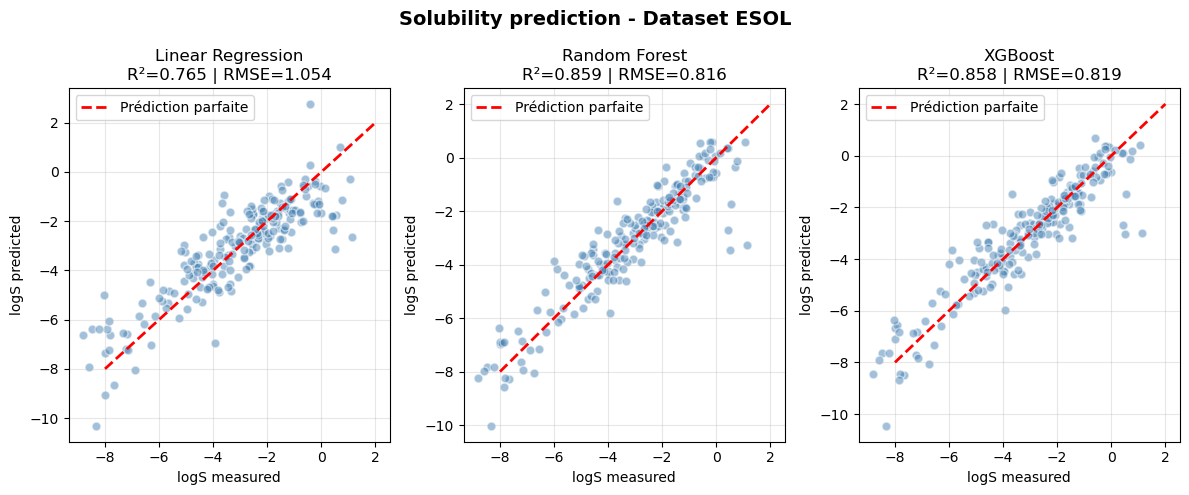

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

for ax, y_pred, title, r2, rmse in zip(
    axes,
    [y_pred_lr, y_pred_rf, y_pred_xgb],
    ['Linear Regression', 'Random Forest', 'XGBoost'],
    [r2_lr, r2_rf, r2_xgb],
    [rmse_lr, rmse_rf, rmse_xgb]
):
    ax.scatter(y_test, y_pred, alpha=0.5, color='steelblue', edgecolors='white', s=40)
    ax.plot([-8, 2], [-8, 2], 'r--', linewidth=2, label='Prédiction parfaite')
    ax.set_xlabel('logS measured')
    ax.set_ylabel('logS predicted')
    ax.set_title(f'{title}\nR²={r2:.3f} | RMSE={rmse:.3f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Solubility prediction - Dataset ESOL', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [48]:
# 1. Calculate aspirin descriptors
aspirine_smiles = "CC(=O)Oc1ccccc1C(=O)O"
descripteurs_aspirine = calculer_descripteurs(aspirine_smiles)
print("Descripteurs :", descripteurs_aspirine)

# 2. Put it in a dataframe
X_aspirine = pd.DataFrame([descripteurs_aspirine])

# 3. OPredict
logS_aspirine = model_rf.predict(X_aspirine)
print(f"logS prédit : {logS_aspirine[0]:.3f}")
print(f"logS expérimental : -1.13")
print(f"Erreur : {abs(logS_aspirine[0] - (-1.13)):.3f}")

Descripteurs : {'LogP': 1.3101, 'MolWt': 180.15899999999996, 'NumHDonors': 1, 'NumHAcceptors': 3, 'TPSA': 63.60000000000001, 'NumAromaticRings': 1}
logS prédit : -1.860
logS expérimental : -1.13
Erreur : 0.730


**Discussion**

Both tree-based models show better results than linear regression (R² 0.77 → 0.86). This improvement was expected as the link between these six descriptors and logS is not linear. Thus models that capture feature interactions show better results.

Between Random Forest and XGBoost the gap is negligible (0.859 vs 0.858). On a single split with only six descriptors, both plateau at essentially the same place. However, the best RMSE (~0.82) is still above the ~0.7 logS experimental noise of solubility measurements. Adding an orthogonal parameter which give global descriptors do not give, such as Morgan fingerprints, could improve the results.

| Model | R² | RMSE |
|---|---|---|
| Linear Regression | 0.765 | 1.054 |
| Random Forest | 0.859 | 0.816 |
| XGBoost | 0.858 | 0.819 |

## 6. Improvement: Morgan Fingerprints
Global descriptors do not capture local structural patterns.
Morgan fingerprints (radius=2, 2048 bits) encode the presence/absence of substructures
around each atom. Combined with descriptors, they enrich the molecular representation.


In [49]:
def calculer_fingerprint(smiles, radius=2, nbits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=nbits)
    return np.array(fp)

# Test sur l'Amygdaline
fp_test = calculer_fingerprint(df['smiles'].iloc[0])
print(f"Taille du fingerprint : {fp_test.shape}")
print(f"Bits actifs : {fp_test.sum()} sur {len(fp_test)}")

Taille du fingerprint : (2048,)
Bits actifs : 44 sur 2048


In [50]:
# Calculate Morgan fingerprints for all molecules
fp_matrix = np.array([calculer_fingerprint(s) for s in df['smiles']])
print(f"Matrix of fingerprints : {fp_matrix.shape}")

# Combiner fingerprints + descripteurs
X_combined = np.hstack([fp_matrix, descripteurs_df.values])
print(f"Combined Dataset : {X_combined.shape}")

y = dataset['logS'].values

Matrix of fingerprints : (1128, 2048)
Combined Dataset : (1128, 2054)


In [51]:
# Split train/test
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_combined, y, test_size=0.2, random_state=42)

#Train Linear Regression
model_lr_combined = LinearRegression()
model_lr_combined.fit(X_train_c, y_train_c)

# Train Random Forest
model_rf_combined = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf_combined.fit(X_train_c,y_train_c)

# Train XGBoost
model_xgb_combined = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model_xgb_combined.fit(X_train_c, y_train_c)

# Evaluate LR
y_pred_combined_lr = model_lr_combined.predict(X_test_c)
r2_lr_combined = r2_score(y_test_c, y_pred_combined_lr)
rmse_lr_combined = np.sqrt(mean_squared_error(y_test_c, y_pred_combined_lr))

#Evaluate RF
y_pred_combined_rf = model_rf_combined.predict(X_test_c)
r2_rf_combined = r2_score(y_test_c, y_pred_combined_rf)
rmse_rf_combined = np.sqrt(mean_squared_error(y_test_c, y_pred_combined_rf))

#Evaluate XGB
y_pred_combined_xgb = model_xgb_combined.predict(X_test_c)
r2_xgb_combined = r2_score(y_test_c, y_pred_combined_xgb)
rmse_xgb_combined = np.sqrt(mean_squared_error(y_test_c, y_pred_combined_xgb))

print(f"LR combined   → R² : {r2_lr_combined:.3f} | RMSE : {rmse_lr_combined:.3f}")
print(f"RF combined   → R² : {r2_rf_combined:.3f} | RMSE : {rmse_rf_combined:.3f}")
print(f"XGB combined   → R² : {r2_xgb_combined:.3f} | RMSE : {rmse_xgb_combined:.3f}")

LR combined   → R² : 0.240 | RMSE : 1.895
RF combined   → R² : 0.866 | RMSE : 0.795
XGB combined   → R² : 0.879 | RMSE : 0.757


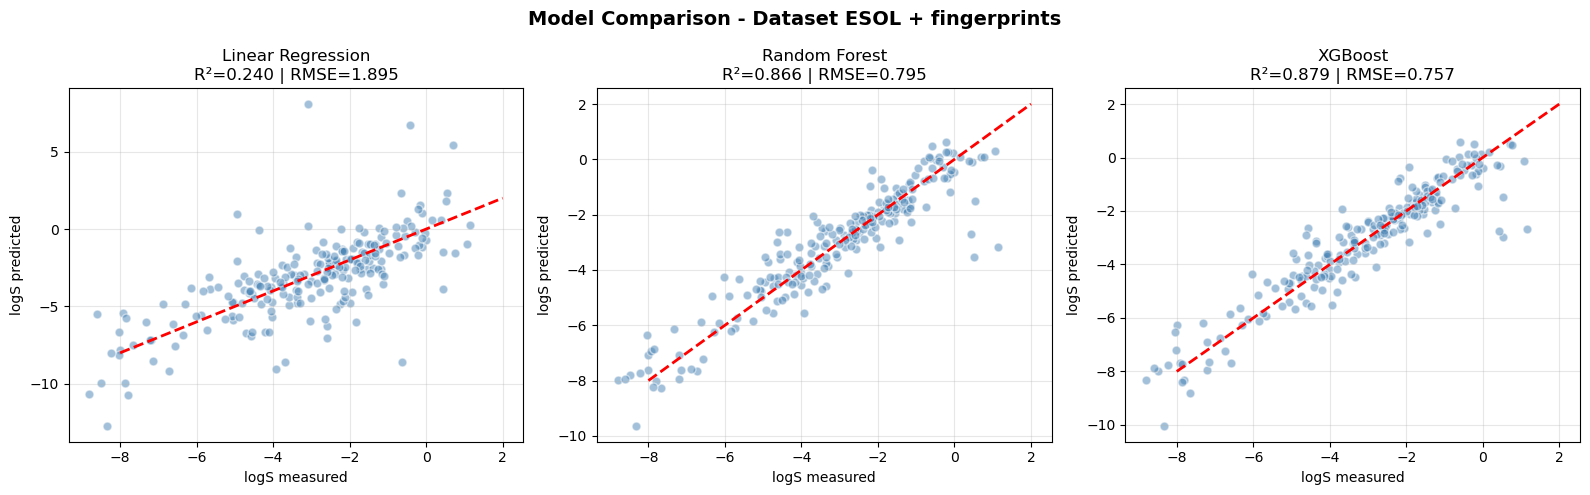

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, y_pred, title, r2, rmse in zip(
    axes,
    [y_pred_combined_lr, y_pred_combined_rf, y_pred_combined_xgb],  
    ['Linear Regression', 'Random Forest', 'XGBoost'], 
    [r2_lr_combined, r2_rf_combined, r2_xgb_combined],  
    [rmse_lr_combined, rmse_rf_combined, rmse_xgb_combined], 
):
    ax.scatter(y_test_c, y_pred, alpha=0.5, color='steelblue', edgecolors='white', s=40)
    ax.plot([-8, 2], [-8, 2], 'r--', linewidth=2)
    ax.set_xlabel('logS measured')
    ax.set_ylabel('logS predicted')
    ax.set_title(f'{title}\nR²={r2:.3f} | RMSE={rmse:.3f}')
    ax.grid(True, alpha=0.3)

plt.suptitle('Model Comparison - Dataset ESOL + fingerprints', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Discussion**

Adding Morgan fingerprints helps, but not uniformly. XGBoost gains the most (R² 0.858 → 0.879, RMSE down to 0.757), while Random Forest is barely impacted. The local substructure patterns give information that global descriptors could not, yet the marginal gain is limited.

On the other hand, the linear regression model collapses from R² 0.77 to 0.24. Going from 6 to 2048 features gave it enough freedom to overfit — with more inputs than it can constrain, and highly correlated bits, it fits the training noise instead of a general trend. Regularization (ridge or lasso) would prevent this.

The best pipeline (XGBoost + descriptors + fingerprints, RMSE 0.757) now sits close to the ~0.7 logS experimental noise of solubility measurements, which makes further gains hard on this dataset.

| Model | R² | RMSE |
|---|---|---|
| Linear Regression | 0.765 | 1.054 |
| Linear Regression combined | 0.240 | 1.894 |
| Random Forest | 0.859 | 0.816 |
| Random Forest combined| 0.866 | 0.795 |
| XGBoost | 0.858 | 0.819 |
| XGBoost combined| 0.879 | 0.757 |

## 7. Evaluation via a scaffold split

To check that the model generalizes to genuinely new chemistry rather than to near-duplicates of the training set, I compare the random split with a Bemis-Murcko scaffold split, which keeps entire scaffold families in either train or test but never both.

In [53]:
import random
from collections import defaultdict
from rdkit.Chem.Scaffolds import MurckoScaffold

def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return MurckoScaffold.MurckoScaffoldSmiles(mol=mol) if mol else None

def scaffold_split(smiles_list, test_size=0.2, seed=42):
    groups = defaultdict(list)
    for i, s in enumerate(smiles_list):
        groups[get_scaffold(s)].append(i)
    sets = list(groups.values())
    random.Random(seed).shuffle(sets)
    n_test, test_idx, train_idx = int(len(smiles_list) * test_size), [], []
    for grp in sets:
        (test_idx if len(test_idx) < n_test else train_idx).extend(grp)
    return train_idx, test_idx

tr, te = scaffold_split(df['smiles'].tolist())
m = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
m.fit(X_combined[tr], y[tr])
pred = m.predict(X_combined[te])
print("XGBoost random split   -> R2: 0.879 | RMSE: 0.757")
print("XGBoost scaffold split -> R2:", round(r2_score(y[te], pred), 3),
      "| RMSE:", round(np.sqrt(mean_squared_error(y[te], pred)), 3))

XGBoost random split   -> R2: 0.879 | RMSE: 0.757
XGBoost scaffold split -> R2: 0.83 | RMSE: 0.842


## 8. Conclusions and Perspectives
XGBoost with fingerprints achieves the best performance (R²=0.879, RMSE=0.757),
approaching the expected level of experimental noise in solubility data (±0.7 logS).

**Identified limitations:**
- Poor predictions for logS > 0 (underrepresented in the dataset)
- 2D descriptors only — no solvation energy or melting point

**Next steps:**
- Extension to organic solvent solubility
- Integration of DFT-derived descriptors

## References

[1] Delaney, J.S. ESOL: Estimating aqueous solubility directly from molecular
structure. *J. Chem. Inf. Comput. Sci.* **44**, 1000–1005 (2004).
https://doi.org/10.1021/ci034243x